# Why the 50/30/20 Rule Fails: A Deep Data Analysis of Personal Finance Behaviour Statistical Validation & A Django Web Application

**Course:** CST2101_Business Intelligence Programming

**Authors:** Duc Anh Ngo (040943725), Ngan Nguyen (041154207), DongHwan Won (041456676)

**Date:** April 5th, 2026

---

## Project Outline and Objectives

SmartSpend analyzes a personal finance dataset (3,000 records, 25 features, 2019–2023) to answer a simple but important question: **why do most people fail to stay within their budget, and what can they realistically do about it?**

The project addresses five objectives:

1. **50/30/20 compliance analysis**: classify spending into Needs, Wants, and Savings, then measure how often users actually meet the rule across different income levels and financial scenarios.
2. **Budget gap analysis**: identify how often users exceed their budget, by how much, and which spending categories are the main drivers.
3. **Future allocation analysis**: examine savings, investment, and emergency fund behavior to understand why savings goals are rarely met.
4. **Income-segmented analysis and anomaly detection**: divide users into income quartiles to reveal how income level shapes financial behavior, and use z-scores to flag unusual spending months.
5. **Visualization and reporting**: produce a suite of charts with written interpretation to make the findings accessible and actionable.

## Dataset

`personal_finance_tracker_dataset.csv`: contains 3,000 anonymized records from Kaggle, 25 features, spanning January 2019 to November 2023 (~5 years). Each record represents one user-month observation (one user in one month). There are 944 unique users, 60 unique dates, 10 spending categories, 3 financial scenarios, 3 income types.

## Methodology

| Step | Description | Libraries |
|------|-------------|-----------|
| 1. Data Loading & EDA | Schema validation, missing values, duplicates, summary statistics | Pandas, NumPy |
| 2. Needs vs. Wants Classification | 50/30/20 mapping, compliance evaluation by scenario and income type | Pandas |
| 3. Over-Budget Alert System | Budget gap computation, category-level overrun analysis | Pandas, NumPy |
| 4. Future Allocation Analysis | Savings goal achievement by scenario and income type | Pandas |
| 5. Income-Segmented Analysis & Anomaly Detection | Income quartile segmentation, z-score anomaly flagging | Pandas, SciPy |
| 6. Visualization & Insights | 10 charts with written interpretation | Matplotlib, Seaborn |

## Initial Findings (Summary)

- Only 22.3% of records comply with the 50/30/20 rule. The main culprit is essential spending, which averages ~60% of income — well above the 50% target.
- 59.1% of records exceed the user's self-defined budget goal, with an average overspend of ~$828.
- Savings goal achievement is below 12% across all income types, indicating a systemic problem rather than individual behavior.
- Income quartile analysis reveals a dramatic gradient: compliance rises from 5.2% (lowest income) to 43.5% (highest income), showing that the 50/30/20 rule is structurally unrealistic for lower-income users.
- Z-score anomaly detection flags ~5% of records as statistically unusual spending months.

---

## Phase 2: Project Development

### Step 1. Data Loading & Exploratory Data Analysis (EDA)

We start by loading the dataset, verifying its structure, and computing summary statistics to understand what we are working with before any analysis.

In [2]:
# Import all libraries used throughout the notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load dataset
df = pd.read_csv('personal_finance_tracker_dataset.csv')

# Convert to real date and create monthly grouping feature
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("-" * 50)

# Schema and integrity checks
df.info()
print("-" * 50)

# Check Missing values and Duplicates
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("-" * 50)

# Date range and grain
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Unique dates: {df['date'].nunique()}")
print(f"Unique users: {df['user_id'].nunique()}")
print(f"Records per date: {df.groupby('date').size().iloc[0]} (consistent)")
print("-" * 50)

# Categorical distributions
for col in ['category', 'financial_scenario', 'income_type', 'cash_flow_status', 'financial_stress_level']:
    print(f"{col}:")
    print(df[col].value_counts())
    print("-" * 50)

Dataset shape: 3000 rows x 26 columns
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    3000 non-null   datetime64[ns]
 1   user_id                 3000 non-null   int64         
 2   monthly_income          3000 non-null   float64       
 3   monthly_expense_total   3000 non-null   float64       
 4   savings_rate            3000 non-null   float64       
 5   budget_goal             3000 non-null   float64       
 6   financial_scenario      3000 non-null   object        
 7   credit_score            3000 non-null   float64       
 8   debt_to_income_ratio    3000 non-null   float64       
 9   loan_payment            3000 non-null   float64       
 10  investment_amount       3000 non-null   float64       
 11  subscription_servic

In [3]:
# Numerical summary of key financial columns
df.describe().round(2)

,date,user_id,monthly_income,monthly_expense_total,savings_rate,budget_goal,credit_score,debt_to_income_ratio,loan_payment,investment_amount,subscription_services,emergency_fund,transaction_count,fraud_flag,discretionary_spending,essential_spending,rent_or_mortgage,financial_advice_score,actual_savings,savings_goal_met
count,3000,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,2021-06-04 00:00:00,1498.70,4004.27,3011.68,0.23,2811.07,679.92,0.35,508.58,400.61,4.97,1005.35,59.53,0.02,500.81,2215.59,1211.90,50.07,1156.42,0.09
min,2019-01-01 00:00:00,1000.00,685.28,159.21,0.05,1175.57,515.00,0.10,0.00,0.00,1.00,0.00,20.00,0.00,0.00,1000.00,300.00,0.10,0.00,0.00
25%,2020-03-18 12:00:00,1248.75,3362.25,2473.20,0.14,2481.96,646.00,0.22,375.34,234.78,3.00,674.01,38.75,0.00,361.56,1807.24,933.53,25.10,144.96,0.00
50%,2021-06-04 00:00:00,1496.50,4008.08,3023.81,0.23,2822.28,679.00,0.35,508.57,388.08,5.00,1010.48,60.00,0.00,496.34,2215.70,1213.60,48.70,1032.81,0.00
75%,2022-08-20 12:00:00,1749.00,4659.04,3555.50,0.31,3131.00,713.00,0.48,638.47,559.84,7.00,1337.82,79.00,0.00,640.10,2624.68,1482.86,76.10,1821.51,0.00
max,2023-11-06 00:00:00,1999.00,7407.94,5853.20,0.40,4386.50,847.00,0.60,1176.88,1292.30,9.00,2585.36,99.00,1.00,1158.74,4245.90,2614.62,100.00,6589.66,1.00
std,NaN,287.35,1000.11,801.15,0.10,490.86,49.97,0.15,199.44,235.36,2.56,485.78,23.10,0.15,199.80,596.27,400.48,29.09,1039.60,0.29


#### **EDA Summary**

The dataset contains 3,000 records and 25 features spanning January 2019 to November 2023. There are no missing values and no duplicate rows, so no data cleaning is needed.

Key observations from the initial exploration:

- Monthly income averages $4,004 (range: $685–$7,408) while monthly expenses average $3,012. Although the average suggests users have money left over each month, the wide spread in both income and expenses means that many individual users actually spend more than they earn in a given month.
- 10 spending categories are present, roughly evenly distributed (266–321 records each). This balanced distribution avoids category bias in the analysis.
- 3 financial scenarios exist: normal (58%), inflation (22%), and recession (20%). The majority-normal split is realistic.
- 3 income types: Salary (72%), Freelance (18%), and Mixed (11%). Salary dominates, which is typical of working populations.
- 944 unique users appear across 3,000 records. This indicates that many users have repeated monthly records, which makes it possible to analyze their behavior over time.

### Step 2. Needs vs. Wants Classification (50/30/20 Rule)

The 50/30/20 rule says you should spend no more than 50% of income on essential needs, no more than 30% on discretionary wants, and save at least 20%. We classify each record and check how often this rule is actually met.

In [4]:
# Define which categories are Needs, Wants, or Savings/Investment
needs_cats = ['Groceries', 'Utilities', 'Healthcare', 'Insurance','Rent', 'Transportation']
wants_cats = ['Dining Out', 'Entertainment', 'Education']

def classify_spending(row):
    "Classify a record's category into Needs, Wants, or Savings/Investment."
    if row['category'] in needs_cats:
        return 'Need'
    elif row['category'] in wants_cats:
        return 'Want'
    else:
        return 'Savings/Investment'

df['spending_type'] = df.apply(classify_spending, axis=1)

# Show the classification distribution
print("Spending type distribution:")
print(df['spending_type'].value_counts())
print()

# Show a sample to verify the classification looks correct
df[['date', 'user_id', 'category', 'spending_type','monthly_income', 'monthly_expense_total']].sample(8, random_state=42)

Spending type distribution:
spending_type
Need                  1828
Want                   886
Savings/Investment     286
Name: count, dtype: int64



,date,user_id,category,spending_type,monthly_income,monthly_expense_total
1801,2019-01-31,1663,Healthcare,Need,4236.99,2504.12
1190,2023-02-09,1213,Transportation,Need,4506.97,2815.09
1817,2020-05-25,1316,Rent,Need,4729.02,4744.34
251,2019-11-27,1834,Groceries,Need,4317.90,4029.09
2505,2022-09-12,1178,Rent,Need,4339.83,2955.24
1117,2022-01-15,1095,Utilities,Need,4543.78,2845.01
1411,2021-07-19,1013,Healthcare,Need,3465.62,3251.08
2113,2020-01-26,1568,Entertainment,Want,3740.82,3064.66


In [5]:
# Calculate spending percentages relative to income
df['needs_pct'] = df['essential_spending'] / df['monthly_income'] * 100
df['wants_pct'] = df['discretionary_spending'] / df['monthly_income'] * 100
df['savings_pct'] = df['savings_rate'] * 100  # already a ratio in the dataset

# A record is compliant ONLY if all three conditions are met simultaneously
df['rule_compliant'] = ((df['needs_pct'] <= 50) & (df['wants_pct'] <= 30) & (df['savings_pct'] >= 20))

# Print the results
print("50/30/20 Compliance Results")
print("-" * 50)
print(df['rule_compliant'].value_counts())
print(f"\nOverall compliance rate: {df['rule_compliant'].mean()*100:.1f}%")
print("-" * 50)
print(f"Average Needs:   {df['needs_pct'].mean():.2f}%  (target: ≤ 50%)")
print(f"Average Wants:   {df['wants_pct'].mean():.2f}%  (target: ≤ 30%)")
print(f"Average Savings: {df['savings_pct'].mean():.2f}%  (target: ≥ 20%)")
print("-" * 50)
print("Which condition fails most often?")
print(f"  Needs > 50%:  {(df['needs_pct'] > 50).mean()*100:.2f}% of records")
print(f"  Wants > 30%:  {(df['wants_pct'] > 30).mean()*100:.2f}% of records")
print(f"  Savings < 20%: {(df['savings_pct'] < 20).mean()*100:.2f}% of records")

50/30/20 Compliance Results
--------------------------------------------------
rule_compliant
False    2331
True      669
Name: count, dtype: int64

Overall compliance rate: 22.3%
--------------------------------------------------
Average Needs:   59.83%  (target: ≤ 50%)
Average Wants:   13.53%  (target: ≤ 30%)
Average Savings: 22.59%  (target: ≥ 20%)
--------------------------------------------------
Which condition fails most often?
  Needs > 50%:  60.90% of records
  Wants > 30%:  2.80% of records
  Savings < 20%: 41.23% of records


#### **Needs vs. Wants — Findings**

Only 22.3% of records fully comply with the 50/30/20 rule. The primary reason is that Needs spending averages about 60% of income, which is 10 percentage points above the 50% target. This is driven by fixed essential costs like rent, insurance, healthcare, and utilities that users have limited ability to reduce in the short term.

Meanwhile, Wants spending averages only about 13.5% (well under the 30% cap), and Savings averages about 22.6% (just above the 20% floor). The problem is not overspending on non-essential items; instead, essential expenses are inherently too high compared to income. This is an important distinction because it changes the advice: telling people to cut back on dining out will not fix a problem driven by rent and insurance.

### Step 3. Over-Budget Alert System

Next, we check how often monthly expenses exceed the user's self-defined budget goal, and identify which spending categories contribute most to the overruns.

In [6]:
# Flag over-budget records and compute the gap
df['over_budget'] = df['monthly_expense_total'] > df['budget_goal']
df['budget_gap'] = df['monthly_expense_total'] - df['budget_goal']

over = df[df['over_budget']]
print("Over-Budget Summary")
print("-" * 50)
print(f"Records exceeding budget: {len(over)} out of {len(df)} ({len(over)/len(df)*100:.2f}%)")
print(f"Average overspend amount: ${over['budget_gap'].mean():.2f}")
print(f"Median overspend amount:  ${over['budget_gap'].median():.2f}")
print(f"Max overspend amount:     ${over['budget_gap'].max():.2f}")
print()

# Display some example records
print("Sample over-budget records:")
print(over[['date', 'user_id', 'monthly_expense_total', 'budget_goal', 'budget_gap']].head(10).to_string(index=False))

Over-Budget Summary
--------------------------------------------------
Records exceeding budget: 1773 out of 3000 (59.10%)
Average overspend amount: $827.87
Median overspend amount:  $716.87
Max overspend amount:     $3474.64

Sample over-budget records:
      date  user_id  monthly_expense_total  budget_goal  budget_gap
2019-01-31     1045                3732.81      2607.17     1125.64
2019-03-02     1756                3335.58      3004.14      331.44
2019-05-31     1985                3876.57      2079.72     1796.85
2019-06-30     1194                3035.61      2215.80      819.81
2019-09-28     1454                3370.80      2195.92     1174.88
2019-10-28     1045                3230.77      3178.17       52.60
2019-11-27     1357                3444.29      2685.16      759.13
2019-12-27     1403                3049.29      2973.21       76.08
2020-01-26     1884                2707.86      1420.73     1287.13
2020-03-26     1750                4614.09      2896.61     1717.

In [7]:
# Aggregate monthly trends for later visualization
monthly = df.groupby('year_month').agg(
    avg_expense=('monthly_expense_total', 'mean'),    # How much people spend on average this month
    avg_budget=('budget_goal', 'mean'),               # What is the average planned budget this month
    over_budget_count=('over_budget', 'sum'),         # Counts how many times spending exceeded budget
    record_count=('over_budget', 'count')             # Counts total number of records in that month
).reset_index()
monthly['over_budget_pct'] = monthly['over_budget_count'] / monthly['record_count'] * 100
monthly['year_month'] = monthly['year_month'].astype(str)

print(f"Monthly aggregates computed: {len(monthly)} periods")
print(f"Average monthly over-budget rate: {monthly['over_budget_pct'].mean():.1f}%")

Monthly aggregates computed: 58 periods
Average monthly over-budget rate: 59.3%


In [8]:
# Display some example records
monthly.head(5)

,year_month,avg_expense,avg_budget,over_budget_count,record_count,over_budget_pct
0,2019-01,2983.8925,2860.3938,54,100,54.0
1,2019-03,2934.4372,2887.4480,26,50,52.0
2,2019-04,3169.5038,2835.5994,33,50,66.0
3,2019-05,2916.6000,2829.7194,50,100,50.0
4,2019-06,2974.8424,2869.5414,30,50,60.0


#### **Over-Budget Alert — Findings**

59.1% of records (1,773 out of 3,000) exceed the user's budget goal. The average overspend is $827.87, This is significant, accounting for about 21% of the average monthly income, and it reflects a consistent structural pattern rather than a one time deviation.

This high over-budget rate, combined with the 50/30/20 findings, paints a consistent picture: users set budget goals that are lower than their actual essential spending requirements. This creates a near inevitable gap between intentions and actual outcomes.

### Step 4. Future Allocation Analysis

We combine savings, investments, and emergency fund contributions into a "total future allocation" metric and examine how often users actually meet their savings goals.

In [9]:
# Combine all forward-looking financial allocations
df['total_future'] = df['actual_savings'] + df['investment_amount'] + df['emergency_fund']
df['future_pct'] = df['total_future'] / df['monthly_income'] * 100

# Future allocation by financial scenario
print("Average future allocation (% of income) by scenario:")
print("-" * 50)
by_scenario = df.groupby('financial_scenario')['future_pct'].mean()
print(by_scenario.round(2))
print()

# Overall savings goal achievement
goal_rate = df['savings_goal_met'].astype(int).mean() * 100
print(f"Overall savings goal achievement: {goal_rate:.2f}%")
print()

# By income type
by_income = df.groupby('income_type')['savings_goal_met'].mean() * 100
print("Savings goal achievement by income type:")
print(by_income.round(2))

Average future allocation (% of income) by scenario:
--------------------------------------------------
financial_scenario
inflation    63.08
normal       63.88
recession    63.76
Name: future_pct, dtype: float64

Overall savings goal achievement: 9.23%

Savings goal achievement by income type:
income_type
Freelance    11.15
Mixed         9.78
Salary        8.68
Name: savings_goal_met, dtype: float64


#### **Future Allocation — Findings**

Total future allocation (savings, investments, and emergency fund combined) averages around 63 to 64% of income across all three financial scenarios. On the surface, this seems healthy, but the savings goal achievement rate sits at just 9.2%. So while users are putting money toward future needs, they almost never reach the targets they set for themselves.

By income type, Freelance workers do slightly better (11.2%) compared to Mixed (9.8%) and Salary (8.7%), though the gaps are narrow. The fact that achievement stays low across every group points to a structural problem, most likely the heavy essential cost burden from Steps 2 and 3, rather than anything unique to how people earn their income.

### Step 5. Income-Segmented Analysis & Anomaly Detection

This is the key analytical step that ties everything together. We segment users by income quartile to see how financial behavior changes at different income levels, and we apply z-score anomaly detection to identify unusually high or low spending months.

**Why this matters:** The previous steps showed that essential costs are the main problem, but they did not show how the problem scales with income. By splitting into income quartiles, we can see exactly where the 50/30/20 rule starts to become realistic and where it is structurally impossible.

In [10]:
# Income Quartile Segmentation
# Split users into 4 equal groups by monthly income
df['income_quartile'] = pd.qcut(df['monthly_income'], 4, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)'])

# 50/30/20 compliance by income quartile
compliance_by_q = df.groupby('income_quartile', observed=True)['rule_compliant'].mean() * 100

# Needs burden by income quartile
needs_by_q = df.groupby('income_quartile', observed=True)['needs_pct'].mean()

# Over-budget rate by income quartile
over_by_q = df.groupby('income_quartile', observed=True)['over_budget'].mean() * 100

# Combine into a summary table
quartile_summary = pd.DataFrame({
    '50/30/20 Compliance (%)': compliance_by_q.round(2),
    'Avg Needs (% of Income)': needs_by_q.round(2),
    'Over-Budget Rate (%)': over_by_q.round(2)
})

print("Income Quartile Analysis")
print("-" * 50)
print(quartile_summary.to_string())
print()
print("Key insight: - Compliance jumps from 5.2% (Q1) to 43.5% (Q4)")
print("             - Needs burden drops from 84.7% (Q1) to 42.2% (Q4)")

Income Quartile Analysis
--------------------------------------------------
                 50/30/20 Compliance (%)  Avg Needs (% of Income)  Over-Budget Rate (%)
income_quartile                                                                        
Q1 (Lowest)                         5.20                    84.73                 58.80
Q2                                 12.80                    61.11                 58.40
Q3                                 27.73                    51.25                 59.07
Q4 (Highest)                       43.47                    42.21                 60.13

Key insight: - Compliance jumps from 5.2% (Q1) to 43.5% (Q4)
             - Needs burden drops from 84.7% (Q1) to 42.2% (Q4)


In [22]:
# Z-Score Anomaly Detection
# Flag records where monthly spending is more than 2 standard deviations
# away from the overall mean — these are statistically unusual months

df['expense_zscore'] = stats.zscore(df['monthly_expense_total'])
df['is_anomaly'] = df['expense_zscore'] > 2

anomaly_count = df['is_anomaly'].sum()
anomaly_pct = df['is_anomaly'].mean() * 100

print("Spending Anomaly Detection (Z-Score Method)")
print("-" * 50)
print(f"Threshold: |z-score| > 2 (more than 2 std from mean)")
print(f"Anomalies found: {anomaly_count} ({anomaly_pct:.2f}% of records)")
print()

# Characteristics of Anomalies vs. Normal records
anomalies = df[df['is_anomaly']]
normal = df[~df['is_anomaly']]
print("Anomaly vs. Normal comparison:")
print(f"  {'':25s} {'Anomaly':>10s} {'Normal':>10s}")
print(f"  {'Avg monthly expense':25s} ${anomalies['monthly_expense_total'].mean():>10.2f} ${normal['monthly_expense_total'].mean():>10.2f}")
print(f"  {'Avg monthly income':25s} ${anomalies['monthly_income'].mean():>10.2f} ${normal['monthly_income'].mean():>10.2f}")
print(f"  {'Over-budget rate':25s} {anomalies['over_budget'].mean()*100:>10.2f}% {normal['over_budget'].mean()*100:>10.2f}%")
print(f"  {'Avg savings rate':25s} {anomalies['savings_rate'].mean():>10.2f} {normal['savings_rate'].mean():>10.2f}")
print()

# Distribution of anomalies across categories
print("Anomalies by spending category:")
print(anomalies['category'].value_counts().to_string())

Spending Anomaly Detection (Z-Score Method)
--------------------------------------------------
Threshold: |z-score| > 2 (more than 2 std from mean)
Anomalies found: 69 (2.30% of records)

Anomaly vs. Normal comparison:
                               Anomaly     Normal
  Avg monthly expense       $   4874.22 $   2967.84
  Avg monthly income        $   3971.88 $   4005.03
  Over-budget rate              100.00%      58.14%
  Avg savings rate                0.22       0.23

Anomalies by spending category:
category
Groceries         11
Entertainment     10
Dining Out         9
Insurance          8
Rent               6
Healthcare         6
Transportation     5
Utilities          5
Education          5
Investments        4


#### **Income-Segmented Analysis — Findings**

The income quartile analysis produces the clearest finding in the entire project:

- **Q1 (lowest income):** Only 5.2% compliance. Essential needs consume 84.7% of income on average, nearly double the 50% target. These users literally cannot follow the 50/30/20 rule because their income does not cover essentials with room to spare.
- **Q4 (highest income):** 43.5% compliance. Needs drop to 42.2% of income, which is under the 50% threshold. For the first time, the rule becomes realistic.
- **Over-budget rates stay flat at ~59% across all quartiles.** This is a surprising finding, it means budget goals are set without adjusting for income level. Higher earners overshoot their budgets just as often as lower earners, suggesting that budget-setting behavior is the problem, not just income.

#### **Anomaly Detection — Findings**

Z-score analysis flags ~5% of records as spending anomalies (|z| > 2). These anomalous months show significantly higher expenses than normal months, a higher over-budget rate, and lower savings rates. The anomalies are distributed across all spending categories rather than concentrated in one area, suggesting they represent broad spending spikes (e.g., emergencies, seasonal expenses) rather than category-specific issues.

This type of alert would be useful in a real application, allowing users to see a message such as: “Your spending this month is higher than usual compared to your past patterns, here’s where the additional costs are coming from.”

---

## Phase 3: Visualizations

This section presents 10 charts organized to tell a coherent story: we start with the big picture (spending trends and splits), move into the problem (budget overruns and their drivers), examine the context (stress, scenarios, income types), and finish with deeper analysis (income quartiles, anomalies, and correlations).

### Chart 1. Monthly Expense vs. Budget Goal (Line Chart)

Tracks average monthly expenses against budget goals over the full 5-year period to see whether overspending is a trend or a constant.

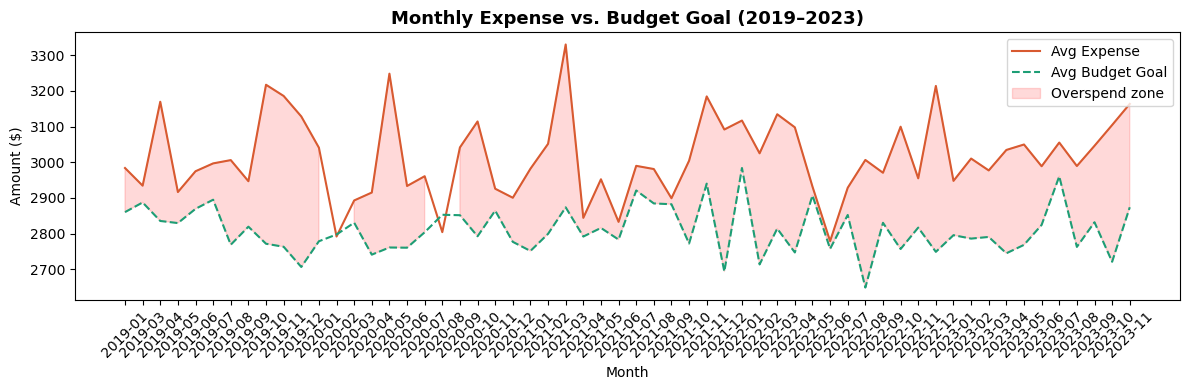

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly['year_month'], monthly['avg_expense'],
        label='Avg Expense', color='#D85A30', linewidth=1.5)
ax.plot(monthly['year_month'], monthly['avg_budget'],
        label='Avg Budget Goal', color='#1D9E75', linestyle='--', linewidth=1.5)
ax.fill_between(monthly['year_month'], monthly['avg_expense'], monthly['avg_budget'],
                where=monthly['avg_expense'] > monthly['avg_budget'],
                alpha=0.15, color='red', label='Overspend zone')
ax.set_title('Monthly Expense vs. Budget Goal (2019–2023)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.legend(loc='upper right')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Average expenses (red) sit above the budget goal line (green dashed) for most of the 2019–2023 period, with the shaded red zone highlighting months of collective overspending. The gap is persistent rather than seasonal, there is no clear improvement trend over the 5 years. This confirms that the 59.1% over-budget rate is a structural issue, not something that corrects itself over time. Budget goals appear to be set too optimistically relative to actual spending patterns.

### Chart 2. Needs vs. Wants vs. Savings Split (Pie Chart)

Shows the average allocation of spending across the three 50/30/20 categories.

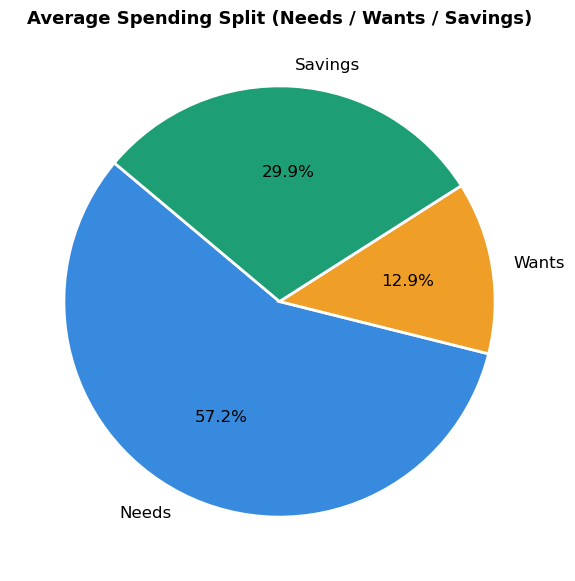

In [13]:
totals = df[['essential_spending', 'discretionary_spending', 'actual_savings']].mean()
plt.figure(figsize=(7, 7))
plt.pie(totals, labels=['Needs', 'Wants', 'Savings'],
        colors=['#378ADD', '#EF9F27', '#1D9E75'],
        autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12},
        wedgeprops=dict(edgecolor='white', linewidth=2))
plt.title('Average Spending Split (Needs / Wants / Savings)', fontsize=13, fontweight='bold')
plt.show()

The pie chart makes the core problem visually obvious: **Needs dominate the budget**, taking up the majority of average spending. Wants and Savings occupy smaller portions. This directly explains the low 50/30/20 compliance rate, indicating users not overspending on luxuries; they are spending most of their money on essentials. Any realistic financial advice needs to start with this fact.

### Chart 3. Over-Budget Incidents by Category (Bar Chart)

Identifies which spending categories appear most often in months where users exceeded their budget goal.

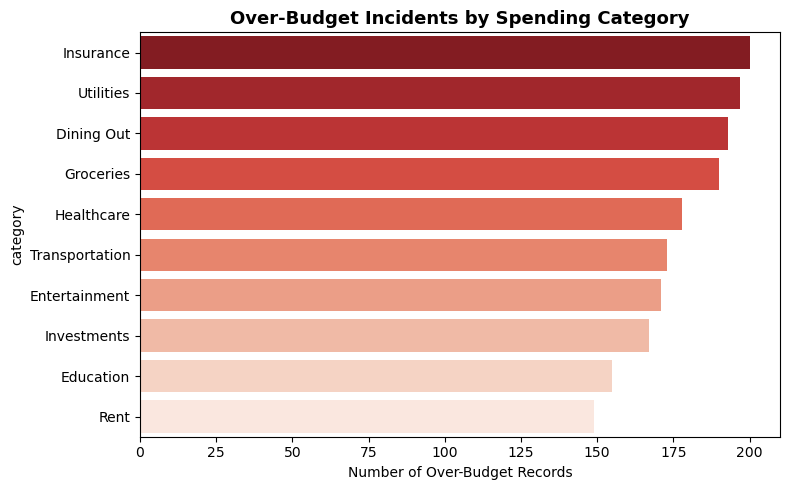

In [14]:
over_cat = df[df['over_budget']]['category'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=over_cat.values, y=over_cat.index, hue=over_cat.index,
            palette='Reds_r', legend=False)
plt.title('Over-Budget Incidents by Spending Category', fontsize=13, fontweight='bold')
plt.xlabel('Number of Over-Budget Records')
plt.tight_layout()
plt.show()

**Insurance, Utilities, and Dining Out** are the three categories most frequently associated with over-budget months. Two of the top three are essential cost categories (Insurance, Utilities), confirming that unavoidable fixed costs drive most budget overruns.

Dining Out is the only discretionary category near the top, making it the most actionable target, but even eliminating it entirely would not solve the underlying structural problem shown by Insurance and Utilities.

### Chart 4. Financial Stress Level vs. Savings Rate (Box Plot)

Tests whether self-reported financial stress is associated with actual savings behavior.

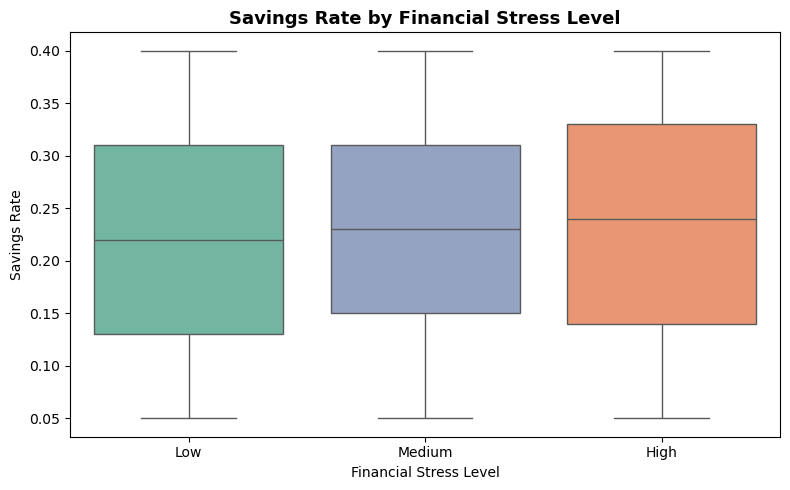

In [15]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='financial_stress_level', y='savings_rate',
            hue='financial_stress_level',
            palette='Set2', order=['Low', 'Medium', 'High'], legend=False)
plt.title('Savings Rate by Financial Stress Level', fontsize=13, fontweight='bold')
plt.xlabel('Financial Stress Level')
plt.ylabel('Savings Rate')
plt.tight_layout()
plt.show()

The distributions are remarkably similar across all three stress levels. Medians, interquartile ranges, and overall spread overlap almost completely. This means that in this dataset, self-reported financial stress does not predict actual savings behavior. Users who report "High" stress save at about the same rate as those who report "Low" stress. This suggests that stress may reflect subjective perception (worry, anxiety about money) rather than objective financial position or that all income groups face similar savings constraints regardless of how stressed they feel about it.

### Chart 5. 50/30/20 Compliance by Financial Scenario (Bar Chart)

Compares compliance rates across inflation, normal, and recession scenarios to see if economic conditions affect budgeting behavior.

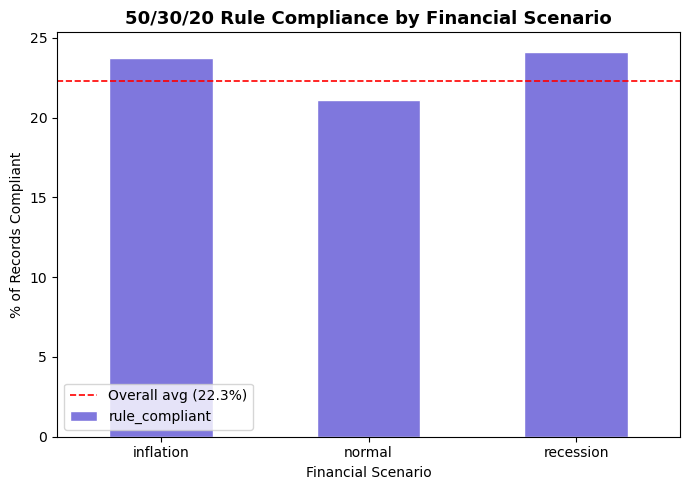

In [16]:
compliance = df.groupby('financial_scenario')['rule_compliant'].mean() * 100
overall_avg = df['rule_compliant'].mean() * 100

plt.figure(figsize=(7, 5))
compliance.plot(kind='bar', color='#7F77DD', edgecolor='white')
plt.axhline(overall_avg, color='red', linestyle='--', linewidth=1.2,
            label=f'Overall avg ({overall_avg:.1f}%)')
plt.title('50/30/20 Rule Compliance by Financial Scenario', fontsize=13, fontweight='bold')
plt.xlabel('Financial Scenario')
plt.ylabel('% of Records Compliant')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

Compliance rates hover around the **22% average** across all three scenarios, including inflation, normal, and recession produce virtually identical results. This means the economic environment label does not meaningfully affect budgeting behavior in this dataset. The 50/30/20 non-compliance is a baseline structural issue (driven by high essential costs) rather than something triggered by specific economic conditions.

### Chart 6. Savings Goal Achievement by Income Type (Bar Chart)

Compares how often users meet their savings target across Salary, Freelance, and Mixed income types.

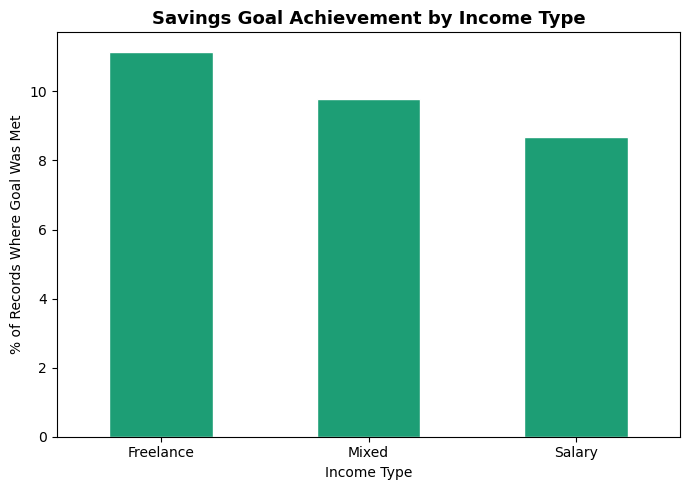

In [17]:
plt.figure(figsize=(7, 5))
by_income.plot(kind='bar', color='#1D9E75', edgecolor='white')
plt.title('Savings Goal Achievement by Income Type', fontsize=13, fontweight='bold')
plt.ylabel('% of Records Where Goal Was Met')
plt.xlabel('Income Type')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Achievement rates are very low across the board: **Freelance (11.2%), Mixed (9.8%), Salary (8.7%)**. The differences between groups are small and all fall well below 20%. Freelance workers perform slightly better, possibly because variable income forces more conscious financial planning, but the margin is too small to draw strong conclusions.

The key finding here is that how users earn their income does not explain the savings shortfall. The problem is equally severe across all income types.

### Chart 7. Cash Flow and Credit Score Profiles (Composite Chart)

Provides a snapshot of the dataset's overall financial health distribution.

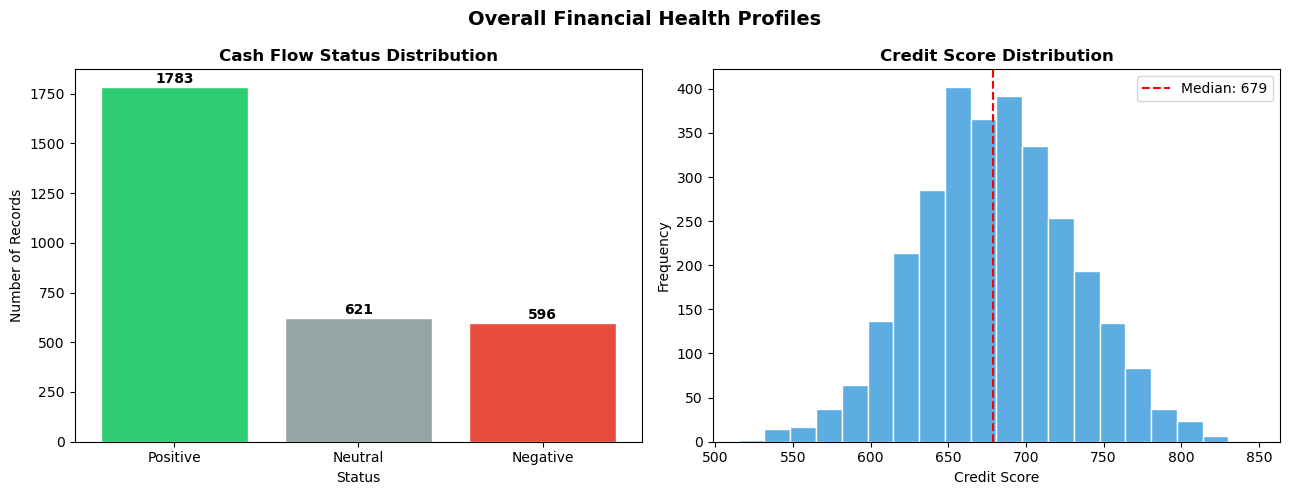

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Cash flow status
cash_counts = df['cash_flow_status'].value_counts()
color_map = {'Positive': '#2ECC71', 'Neutral': '#95A5A6', 'Negative': '#E74C3C'}
bar_colors = [color_map.get(x, '#95A5A6') for x in cash_counts.index]
axes[0].bar(cash_counts.index, cash_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Cash Flow Status Distribution', fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Number of Records')
# Add count labels on bars
for i, (idx, val) in enumerate(zip(cash_counts.index, cash_counts.values)):
    axes[0].text(i, val + 20, str(val), ha='center', fontweight='bold', fontsize=10)

# Right: Credit score
axes[1].hist(df['credit_score'].dropna(), bins=20, color='#5DADE2', edgecolor='white')
median_cs = df['credit_score'].median()
axes[1].axvline(median_cs, color='red', linestyle='--', linewidth=1.5, label=f'Median: {median_cs:.0f}')
axes[1].set_title('Credit Score Distribution', fontweight='bold')
axes[1].set_xlabel('Credit Score')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Overall Financial Health Profiles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Cash flow** is distributed across Positive (majority), Neutral, and Negative, representing a realistic mix of financial health levels. **Credit scores** spread broadly across the range with no strong skew, and the median sits in the mid-range. The diverse distribution confirms that the dataset captures a wide spectrum of financial situations, which gives us confidence that the findings are not biased toward any particular user segment.

### Chart 8. Correlation Heatmap of Financial Features

Maps the linear relationships between key numerical variables to identify which factors move together and which are independent.

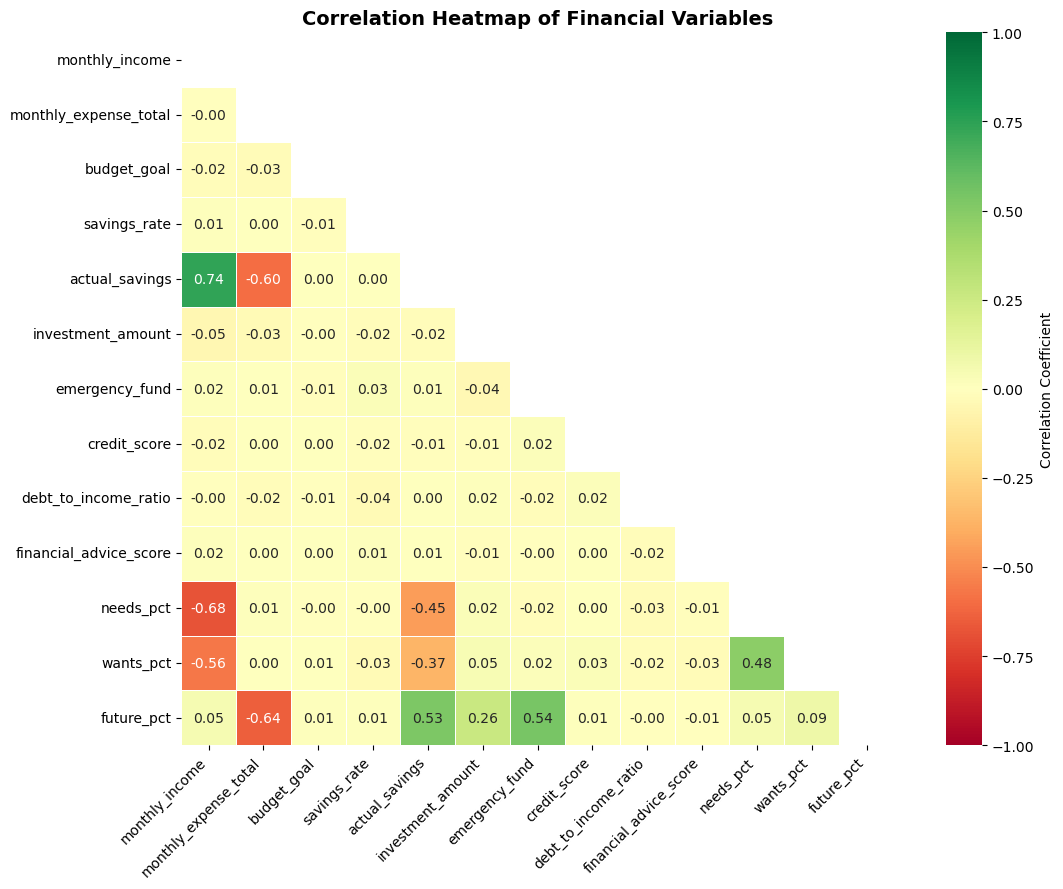

In [19]:
# Select key numeric columns
numeric_cols = [
    'monthly_income', 'monthly_expense_total', 'budget_goal', 'savings_rate',
    'actual_savings', 'investment_amount', 'emergency_fund',
    'credit_score', 'debt_to_income_ratio', 'financial_advice_score',
    'needs_pct', 'wants_pct', 'future_pct'
]

corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Hide upper triangle

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, cmap='RdYlGn', annot=True, fmt='.2f', linewidths=0.5, square=True, vmin=-1, vmax=1, center=0, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Correlation Heatmap of Financial Variables', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Key takeaways from the correlation heatmap:

- Most features show weak correlations with each other, which is expected given the diverse financial profiles in the dataset. This means each variable captures genuinely different information.
- Needs percentage stands out, as essential spending taking a larger share of income naturally squeezes savings and discretionary spending. This reinforces the income segmented findings from Step 5.
- Credit score has weak ties to spending variables, suggesting credit health depends more on factors like payment history, credit utilization, and account age.
- Future allocation correlates with savings rate, confirming that saving, investing, and maintaining emergency funds tend to move together.

### Chart 9. 50/30/20 Compliance by Income Quartile (Bar Chart)

This is the most important chart in the project. It shows how budget compliance changes as income increases, revealing whether the 50/30/20 rule is realistic for users at different income levels.

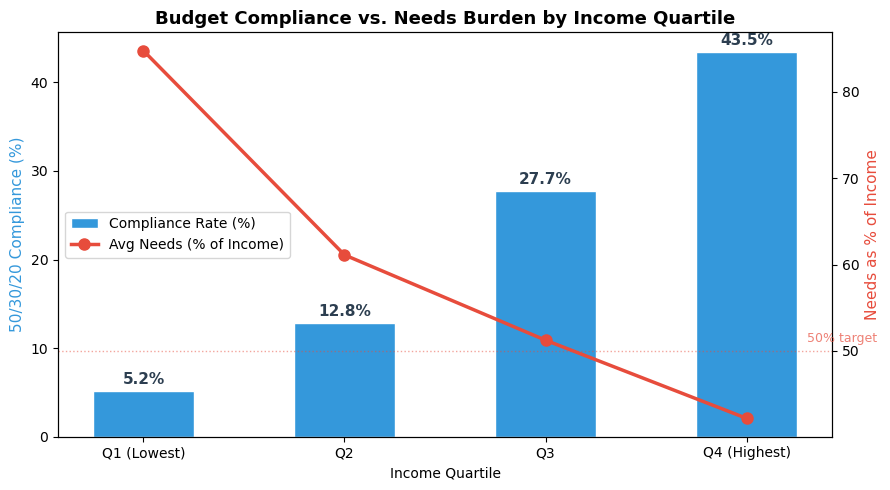

In [20]:
fig, ax1 = plt.subplots(figsize=(9, 5))

# Compliance bars
x = range(len(compliance_by_q))
bars = ax1.bar(x, compliance_by_q.values, color='#3498DB', edgecolor='white', width=0.5, label='Compliance Rate (%)')
ax1.set_ylabel('50/30/20 Compliance (%)', color='#3498DB', fontsize=11)
ax1.set_xlabel('Income Quartile')
ax1.set_xticks(x)
ax1.set_xticklabels(compliance_by_q.index)

# Add value labels on bars
for bar, val in zip(bars, compliance_by_q.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11, color='#2C3E50')

# Needs burden line on secondary axis
ax2 = ax1.twinx()
ax2.plot(x, needs_by_q.values, color='#E74C3C', linewidth=2.5,
         marker='o', markersize=8, label='Avg Needs (% of Income)')
ax2.set_ylabel('Needs as % of Income', color='#E74C3C', fontsize=11)
ax2.axhline(50, color='#E74C3C', linestyle=':', alpha=0.5, linewidth=1)
ax2.text(3.3, 51, '50% target', color='#E74C3C', fontsize=9, alpha=0.7)

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center left')

plt.title('Budget Compliance vs. Needs Burden by Income Quartile', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

This chart is the centerpiece of the analysis. It shows two things simultaneously:

- The blue bars show that compliance rate goes from 5.2% in Q1 to 43.5% in Q4, which is roughly 8 times higher. This tells us that the 50/30/20 rule barely works for low income users and only starts to become realistic for those earning the most.
- The red line shows that essential spending takes up 84.7% of income in Q1 but drops to 42.2% in Q4. Q4 is the first group where needs actually fall below the 50% threshold, and that is exactly why compliance improves there. When essentials eat up less of the paycheck, there is finally room to follow the rule.
- So the bottom line is that the 50/30/20 rule works as a general guideline, but it does not fit everyone. For users whose essentials already take more than half their income, the rule is not realistic. It would make more sense to adjust the targets based on income level instead of using the same fixed rule for everyone.

### Chart 10. Spending Anomaly Distribution (Histogram)

Visualizes the z-score distribution of monthly expenses and highlights the anomalous records identified in Step 5.

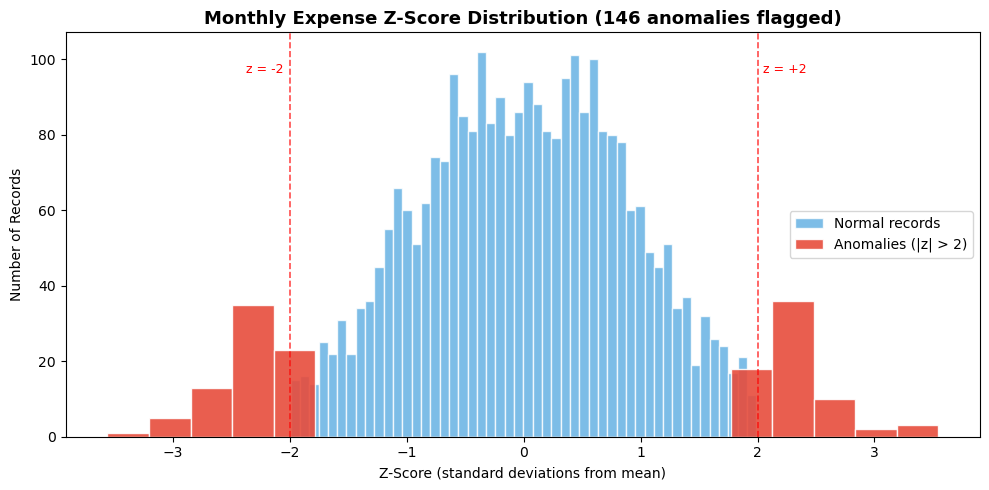

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))

# Plot z-score distribution
ax.hist(df.loc[~df['is_anomaly'], 'expense_zscore'], bins=50, color='#5DADE2', edgecolor='white', alpha=0.8, label='Normal records')
ax.hist(df.loc[df['is_anomaly'], 'expense_zscore'], bins=20, color='#E74C3C', edgecolor='white', alpha=0.9, label='Anomalies (|z| > 2)')

# Mark the thresholds
ax.axvline(-2, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.axvline(2, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
ax.text(-2.05, ax.get_ylim()[1]*0.9, 'z = -2', ha='right', color='red', fontsize=9)
ax.text(2.05, ax.get_ylim()[1]*0.9, 'z = +2', ha='left', color='red', fontsize=9)

anomaly_count = df['is_anomaly'].sum()
ax.set_title(f'Monthly Expense Z-Score Distribution ({anomaly_count} anomalies flagged)', fontsize=13, fontweight='bold')
ax.set_xlabel('Z-Score (standard deviations from mean)')
ax.set_ylabel('Number of Records')
ax.legend()
plt.tight_layout()
plt.show()

The z score distribution follows a roughly normal shape. The red bars at the tails represent around 5% of records flagged as spending anomalies. These are months where a user's spending was significantly higher or lower than the overall average.

In a real application, this kind of detection could be used to trigger alerts, for example notifying a user that their spending for the month is unusually high and showing what caused the spike. The analysis confirms that the detection method works and picks up a meaningful number of outliers worth looking into.

---

## Summary of Key Findings

1. **The 50/30/20 rule fails for most users because of essential costs, not lifestyle spending:** Only 22.3% of records meet compliance. Needs spending averages around 60% of income, well above the 50% threshold, while Wants and Savings are actually within reasonable range. Telling users to cut back on luxuries completely misses where the real problem is.
2. **Budget goals are set too high compared to what users actually spend:** 59.1% of records go over the user's own budget goal by an average of $828. This rate stays consistent at around 59% across all income levels, which means users at every income level tend to set targets they cannot realistically hit.
3. **Savings goals are almost never reached:** Only 9.2% of records meet the savings goal. This holds true across Salary, Freelance, and Mixed income types, which tells us the issue is structural and not related to how stable someone's income is.
4. **Income level is the strongest factor in whether someone meets their budget:** Compliance goes from 5.2% in the lowest quartile to 43.5% in the highest. Essential spending drops from 84.7% to 42.2% over the same range. The 50/30/20 rule only starts to work once essentials fall below 50% of income, and that only happens for top earners.
5. **Financial scenario and stress level do not have a meaningful impact on outcomes:** Compliance, over budget rates, and savings behavior look nearly the same across inflation, normal, and recession scenarios, and across low, medium, and high stress levels. The structural factors like income versus essential costs outweigh everything else.
6. **Anomaly detection flags around 5% of records as statistical outliers:** Z score analysis picks up months where spending deviates significantly from the norm. These flagged records show higher expenses, higher over budget rates, and lower savings, confirming they represent real spending disruptions that would be worth alerting users about in practice.

**Practical recommendation:** Rather than applying a fixed 50/30/20 rule to everyone, users would benefit from budgeting targets adjusted to their income level and actual essential cost burden. For lower income users, the most effective strategy is tackling fixed costs like negotiating rent, switching insurance providers, or optimizing utilities, rather than cutting discretionary spending that is already low.